<a href="https://colab.research.google.com/github/Allen41747/claude-code/blob/main/EV_Cell_Affinity_Pipeline_(TXT_Support).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EV–Cell Interaction Affinity Prediction Pipeline
### CS Master's Dissertation | AI-Driven Computational Filter for Extracellular Vesicle Targeting

**Project Goal:** Predict macroscopic, set-to-set interaction affinities between Extracellular Vesicles (EVs) and Target Cells using a high-speed AI pipeline — acting as a rapid first-pass screening tool before expensive wet-lab experiments or 3D AlphaFold simulations.

---

## Pipeline Overview

```
Lab Mass Spec CSV
      │
      ▼
build_dataset.py  ──► UniProt REST API ──► Local FASTA CSV
      │
      ▼
tokenization.py   ──► ESM-2 Tokenizer  ──► Token Tensors
      │
      ▼
ESM-2 Transformer ──► Cross-Attention Query ──► Fixed-Size Embeddings
      │
      ▼
Pairwise Neural Classifier ──► P(A, B) Matrix
      │
      ▼
Aggregation Function g() ──► Scalar Affinity Score T
      │
      ▼
Streamlit / Gradio UI
```

## 0. Environment Setup
Install and verify all required dependencies.

In [ ]:
# Install dependencies (run once)
# !conda create -n ev_pipeline python=3.10 -y
# !pip install torch transformers requests pandas numpy scipy tqdm

import sys
import torch
import transformers
import pandas as pd
import numpy as np
import requests

print(f"Python:       {sys.version.split()[0]}")
print(f"PyTorch:      {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"CUDA:         {torch.cuda.is_available()} | Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
print(f"Pandas:       {pd.__version__}")

Python:       3.12.13
PyTorch:      2.10.0+cpu
Transformers: 5.0.0
CUDA:         False | Device: CPU
Pandas:       2.2.2


---
## 1. Data Ingestion: `build_dataset.py`

Parses lab-provided mass spectrometry CSVs containing **UniProt Accession IDs** and **abundance weights** (e.g. `1.83E+04`), pings the UniProt REST API with rate-limiting, and outputs a clean local ML-ready CSV of FASTA sequences.

In [ ]:
import time
import logging
from pathlib import Path

logging.basicConfig(level=logging.INFO, format="%(asctime)s — %(levelname)s — %(message)s")
logger = logging.getLogger(__name__)

UNIPROT_API_BASE = "https://rest.uniprot.org/uniprotkb"
RATE_LIMIT_DELAY = 0.5  # seconds between requests (UniProt throttle compliance)
OUTPUT_PATH = Path("data/ev_fasta_dataset.csv")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)


def parse_mass_spec_csv(filepath: str, delimiter: str = ',') -> pd.DataFrame:
    """
    Parse lab-provided mass spectrometry CSV or TXT files.
    Expected columns: UniProt Accession ID, Abundance Weight
    """
    df = pd.read_csv(filepath, delimiter=delimiter)
    logger.info(f"Loaded {len(df)} rows from {filepath}")
    logger.info(f"Columns: {df.columns.tolist()}")

    # Normalise abundance weights (scientific notation → float)
    df["abundance_weight"] = df["abundance_weight"].apply(
        lambda x: float(x) if pd.notna(x) else 0.0
    )
    return df


def fetch_fasta_from_uniprot(accession_id: str, retries: int = 3) -> str | None:
    """
    Ping UniProt REST API to retrieve FASTA sequence for a given accession ID.
    Includes retry logic and rate limiting.
    """
    url = f"{UNIPROT_API_BASE}/{accession_id}.fasta"
    for attempt in range(retries):
        try:
            response = requests.get(url, timeout=10)
            if response.status_code == 200:
                # Strip FASTA header, return sequence only
                lines = response.text.strip().split("\n")
                sequence = "".join(lines[1:])  # skip the >sp|... header
                return sequence
            elif response.status_code == 404:
                logger.warning(f"Accession {accession_id} not found (404).")
                return None
            else:
                logger.warning(f"Attempt {attempt+1} failed for {accession_id}: HTTP {response.status_code}")
        except requests.RequestException as e:
            logger.error(f"Request error for {accession_id}: {e}")
        time.sleep(RATE_LIMIT_DELAY * (attempt + 1))  # exponential back-off
    return None


def build_dataset(mass_spec_filepath: str, delimiter: str = ',') -> pd.DataFrame:
    """
    Full pipeline: parse CSV/TXT → fetch FASTA sequences → save ML-ready dataset.
    """
    df = parse_mass_spec_csv(mass_spec_filepath, delimiter=delimiter)

    fasta_sequences = []
    for i, row in df.iterrows():
        accession_id = row["uniprot_accession"]
        logger.info(f"[{i+1}/{len(df)}] Fetching: {accession_id}")
        fasta = fetch_fasta_from_uniprot(accession_id)
        fasta_sequences.append(fasta)
        time.sleep(RATE_LIMIT_DELAY)  # strict rate limiting

    df["fasta_sequence"] = fasta_sequences
    df_clean = df.dropna(subset=["fasta_sequence"]).reset_index(drop=True)

    df_clean.to_csv(OUTPUT_PATH, index=False)
    logger.info(f"Saved {len(df_clean)} sequences to {OUTPUT_PATH}")
    return df_clean


# --- DEMO (replace with real CSV/TXT path) ---
# df_dataset = build_dataset("data/lab_mass_spec.csv")
# df_dataset.head()

print("build_dataset module loaded successfully.")
print(f"Output will be saved to: {OUTPUT_PATH}")

build_dataset module loaded successfully.
Output will be saved to: data/ev_fasta_dataset.csv


### 1.1 Inspect Sample Dataset

In [ ]:
# Simulate a sample dataset for demonstration purposes
sample_data = {
    "uniprot_accession": ["P04637", "P00533", "P01308", "Q9BYF1"],
    "protein_name":      ["TP53",   "EGFR",   "Insulin", "ACE2"],
    "abundance_weight":  ["1.83E+04", "2.45E+05", "9.12E+03", "3.67E+04"],
    "source":            ["EV",     "EV",      "Target",  "Target"]
}

df_sample = pd.DataFrame(sample_data)
df_sample["abundance_weight"] = df_sample["abundance_weight"].apply(float)

print("Sample Mass Spec CSV structure:")
print(df_sample.to_string(index=False))
print(f"\nAbundance weight range: {df_sample['abundance_weight'].min():.2e} — {df_sample['abundance_weight'].max():.2e}")

Sample Mass Spec CSV structure:
uniprot_accession protein_name  abundance_weight source
           P04637         TP53           18300.0     EV
           P00533         EGFR          245000.0     EV
           P01308      Insulin            9120.0 Target
           Q9BYF1         ACE2           36700.0 Target

Abundance weight range: 9.12e+03 — 2.45e+05


---
## 2. Tokenization: `tokenization.py`

Push the local FASTA dataset through the HuggingFace **ESM-2 tokenizer** to verify tensor shape outputs before feeding into the transformer backbone.

In [ ]:
from transformers import EsmTokenizer, EsmModel

# ESM-2 model checkpoint (150M params — good balance of speed vs. accuracy for MVP)
ESM2_CHECKPOINT = "facebook/esm2_t30_150M_UR50D"

print(f"Loading ESM-2 tokenizer from: {ESM2_CHECKPOINT}")
tokenizer = EsmTokenizer.from_pretrained(ESM2_CHECKPOINT)
print("Tokenizer loaded successfully.")

# Sample sequences of varying lengths to test tensor shapes
test_sequences = [
    "MKTAYIAKQRQISFVKSHFSRQLEERLGLIEVQAPILSRVGDGTQDNLSGAEKAVQVKVKALPDAQFEVVHSLAKWKRQTLGQHDFSAGEGLYTHMKALRPDEDRLSPLHSVYVDQWDWERVMGDGERQFSTLKSTVEAIWAGIKATEAAVSEEFGLAPFLPDQIHFVHSQELLSRYPDLDAKGRERAIAKDLGAVFLVGIGGKLSDGHRHDVRAPDYDDWSTPSELGHAGLNGDILVWNPVLEDAFELSSMGIRVDADTLKHQLALTGEDEDtokenizationsample",
    "ACDEFGHIKLMNPQRSTVWY",  # short sequence ~20 AA
    "MAEGEITTFTALTEKFNLPPGNYKKPKLLYCSNGGHFLRILPDGTVDGTRDRSDQHIQLQLSAESVGEVYIKSTETGQYLAMDTSGLLYGSQTPSEECLFLERLEENHYNTYTSKKHAEKNWFVGLKKNGSCKRGPRTHYGQKAILFLPLPV"  # medium ~150 AA
]

print("\nTokenizing sequences of varying lengths:")
print("-" * 60)

for i, seq in enumerate(test_sequences):
    tokens = tokenizer(
        seq,
        return_tensors="pt",
        padding=False,
        truncation=True,
        max_length=1024
    )
    seq_len = tokens["input_ids"].shape[1]
    print(f"Sequence {i+1}: AA length = {len(seq):>4} | Token tensor shape = {tokens['input_ids'].shape}")

print("-" * 60)
print("\n⚠ Note: variable token lengths (L) are the core tensor shape challenge.")
print("  The Cross-Attention Query mechanism addresses this — see Section 3.")

Loading ESM-2 tokenizer from: facebook/esm2_t30_150M_UR50D


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/95.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/93.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Tokenizer loaded successfully.

Tokenizing sequences of varying lengths:
------------------------------------------------------------
Sequence 1: AA length =  291 | Token tensor shape = torch.Size([1, 276])
Sequence 2: AA length =   20 | Token tensor shape = torch.Size([1, 22])
Sequence 3: AA length =  152 | Token tensor shape = torch.Size([1, 154])
------------------------------------------------------------

⚠ Note: variable token lengths (L) are the core tensor shape challenge.
  The Cross-Attention Query mechanism addresses this — see Section 3.


---
## 3. Model Architecture — Task 1: Pairwise Neural Classification

### 3.1 The Variable-Length Problem

Amino acid sequences vary from **~50 to ~3000** residues. Zero-padding to max length causes:
- **OOM (Out-of-Memory) crashes** on GPU
- Loss of local binding pocket feature signals

### 3.2 Solution: Cross-Attention Query Mechanism

A learned **Query Sequence** tensor $Q \in \mathbb{R}^{K \times d}$ (fixed size) attends over the dynamic ESM-2 output $H \in \mathbb{R}^{L \times d}$ (variable length), distilling features into a strict fixed-size representation:

$$\text{Attn}(Q, H, H) = \text{softmax}\left(\frac{QH^T}{\sqrt{d}}\right) H \quad \Rightarrow \quad \mathbb{R}^{K \times d}$$

### 3.3 Symmetry Constraint

Biological interactions are undirected, so the model must satisfy:

$$P(A, B) = P(B, A)$$

Implemented via **positional identifier tokens** ensuring order-invariance.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import EsmModel


class CrossAttentionPooling(nn.Module):
    """
    Solves the variable-length tensor problem.

    A learnable Query matrix Q (K × d) attends over dynamic ESM-2 output
    H (L × d) to produce a fixed-size representation (K × d), where:
      - K = number of query slots (hyperparameter, e.g. 16)
      - d = ESM-2 hidden dimension (480 for 150M model)
      - L = variable sequence length
    """
    def __init__(self, hidden_dim: int = 480, num_queries: int = 16):
        super().__init__()
        self.num_queries = num_queries
        self.hidden_dim = hidden_dim

        # Learnable query: shape (K, d)
        self.query = nn.Parameter(torch.randn(num_queries, hidden_dim))

        # Multi-head cross-attention
        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=8,
            batch_first=True
        )

    def forward(self, esm_output: torch.Tensor) -> torch.Tensor:
        """
        Args:
            esm_output: ESM-2 last hidden state  (batch, L, d)  — variable L
        Returns:
            fixed_repr: Fixed-size representation (batch, K*d)  — always same size
        """
        batch_size = esm_output.size(0)

        # Expand learnable query for batch
        query = self.query.unsqueeze(0).expand(batch_size, -1, -1)  # (B, K, d)

        # Cross-attention: Q attends to dynamic ESM-2 output
        attn_out, _ = self.cross_attn(
            query=query,          # (B, K, d)
            key=esm_output,       # (B, L, d)
            value=esm_output      # (B, L, d)
        )  # → (B, K, d)

        # Flatten to fixed vector
        return attn_out.reshape(batch_size, -1)  # (B, K*d)


class SymmetricPairwiseClassifier(nn.Module):
    """
    Task 1 Architecture: Pairwise Neural Classification

    Computes P(A, B) = P(B, A) — the interaction probability between two proteins.
    Symmetry is enforced by taking the element-wise sum of the two protein embeddings
    before classification, which is order-invariant.

    Architecture:
      ESM-2 Backbone → CrossAttentionPooling → Fixed Embedding
                                              ↓
      [emb_A + emb_B] → MLP Classifier → P(A, B) ∈ [0, 1]
    """
    def __init__(
        self,
        esm_checkpoint: str = "facebook/esm2_t30_150M_UR50D",
        hidden_dim: int = 480,
        num_queries: int = 16,
        freeze_esm: bool = True
    ):
        super().__init__()

        # ESM-2 Backbone (pre-trained, optionally frozen)
        self.esm = EsmModel.from_pretrained(esm_checkpoint)
        if freeze_esm:
            for param in self.esm.parameters():
                param.requires_grad = False
            print("ESM-2 backbone frozen — only classifier head will be trained.")

        # Cross-attention pooling
        self.pooling = CrossAttentionPooling(hidden_dim=hidden_dim, num_queries=num_queries)

        # MLP classifier head
        embed_size = num_queries * hidden_dim  # K * d
        self.classifier = nn.Sequential(
            nn.Linear(embed_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def encode(self, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        """Encode a single protein sequence to a fixed-size embedding."""
        esm_out = self.esm(input_ids=input_ids, attention_mask=attention_mask)
        return self.pooling(esm_out.last_hidden_state)

    def forward(
        self,
        input_ids_a: torch.Tensor, attention_mask_a: torch.Tensor,
        input_ids_b: torch.Tensor, attention_mask_b: torch.Tensor
    ) -> torch.Tensor:
        """
        Compute P(A, B) = P(B, A).

        Symmetry enforcement: emb_A + emb_B is commutative.
        """
        emb_a = self.encode(input_ids_a, attention_mask_a)
        emb_b = self.encode(input_ids_b, attention_mask_b)

        # Symmetric combination — order invariant
        combined = emb_a + emb_b  # (B, K*d)

        return self.classifier(combined).squeeze(-1)  # (B,) ∈ [0, 1]


# --- Architecture summary ---
print("SymmetricPairwiseClassifier Architecture:")
print("  ESM-2 (facebook/esm2_t30_150M_UR50D) → CrossAttentionPooling (K=16) → MLP → P(A,B)")
print(f"  Fixed embedding size: 16 queries × 480 dim = {16 * 480:,}")
print("\nSymmetry check: P(A,B) = sigmoid(MLP(emb_A + emb_B)) = sigmoid(MLP(emb_B + emb_A)) = P(B,A) ✓")

SymmetricPairwiseClassifier Architecture:
  ESM-2 (facebook/esm2_t30_150M_UR50D) → CrossAttentionPooling (K=16) → MLP → P(A,B)
  Fixed embedding size: 16 queries × 480 dim = 7,680

Symmetry check: P(A,B) = sigmoid(MLP(emb_A + emb_B)) = sigmoid(MLP(emb_B + emb_A)) = P(B,A) ✓


### 3.4 Architecture Smoke Test

In [ ]:
# Smoke test: verify shapes and symmetry without loading full ESM-2
# (Simulates the forward pass using random tensors)

torch.manual_seed(42)

BATCH_SIZE = 2
HIDDEN_DIM = 480  # ESM-2 150M hidden dim
NUM_QUERIES = 16

# Simulate variable-length ESM-2 outputs
seq_len_A = 350  # e.g. protein A is 350 tokens
seq_len_B = 127  # e.g. protein B is 127 tokens

esm_out_A = torch.randn(BATCH_SIZE, seq_len_A, HIDDEN_DIM)  # (B, L_A, d)
esm_out_B = torch.randn(BATCH_SIZE, seq_len_B, HIDDEN_DIM)  # (B, L_B, d)  ← different L!

# CrossAttentionPooling: maps variable L → fixed K*d
pooler = CrossAttentionPooling(hidden_dim=HIDDEN_DIM, num_queries=NUM_QUERIES)

fixed_A = pooler(esm_out_A)
fixed_B = pooler(esm_out_B)

print("=" * 55)
print("Cross-Attention Pooling — Shape Verification")
print("=" * 55)
print(f"ESM-2 output A:  {tuple(esm_out_A.shape)}  (variable L={seq_len_A})")
print(f"ESM-2 output B:  {tuple(esm_out_B.shape)}  (variable L={seq_len_B})")
print(f"Fixed emb A:     {tuple(fixed_A.shape)}  ← always K*d")
print(f"Fixed emb B:     {tuple(fixed_B.shape)}  ← always K*d")
print()

# Symmetry verification
combined_AB = fixed_A + fixed_B
combined_BA = fixed_B + fixed_A
symmetric = torch.allclose(combined_AB, combined_BA)
print(f"Symmetry check (emb_A + emb_B == emb_B + emb_A): {symmetric} ✓" if symmetric else "SYMMETRY FAILED ✗")
print("=" * 55)

Cross-Attention Pooling — Shape Verification
ESM-2 output A:  (2, 350, 480)  (variable L=350)
ESM-2 output B:  (2, 127, 480)  (variable L=127)
Fixed emb A:     (2, 7680)  ← always K*d
Fixed emb B:     (2, 7680)  ← always K*d

Symmetry check (emb_A + emb_B == emb_B + emb_A): True ✓


---
## 4. Training Data Strategy

| Data Source | Role | Count |
|---|---|---|
| **CellPhoneDB** | Positive interactions (known EV-cell binding pairs) | ~3,000 |
| **STRING DB** | Hard negatives (non-interacting protein pairs) | ~3,000 |
| **Total** | Balanced training set | ~6,000 |

> **Why not use all 11M STRING rows?** GPU training would take weeks. Curated hard negatives preserve signal quality and enable rapid iteration (hours per epoch).

In [ ]:
from torch.utils.data import Dataset, DataLoader


class ProteinPairDataset(Dataset):
    """
    Dataset of protein pairs with binary interaction labels.

    Label 1: interacting pair (from CellPhoneDB positives)
    Label 0: non-interacting pair (hard negatives from STRING)
    """
    def __init__(self, pairs_df: pd.DataFrame, tokenizer, max_length: int = 512):
        self.pairs = pairs_df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        row = self.pairs.iloc[idx]

        tok_a = self.tokenizer(
            row["sequence_a"], return_tensors="pt",
            truncation=True, max_length=self.max_length,
            padding="max_length"
        )
        tok_b = self.tokenizer(
            row["sequence_b"], return_tensors="pt",
            truncation=True, max_length=self.max_length,
            padding="max_length"
        )

        return {
            "input_ids_a":      tok_a["input_ids"].squeeze(0),
            "attention_mask_a": tok_a["attention_mask"].squeeze(0),
            "input_ids_b":      tok_b["input_ids"].squeeze(0),
            "attention_mask_b": tok_b["attention_mask"].squeeze(0),
            "label":            torch.tensor(row["label"], dtype=torch.float32)
        }


def get_class_balance(df: pd.DataFrame) -> None:
    """Print class distribution."""
    counts = df["label"].value_counts()
    total = len(df)
    print("Training Set Class Distribution:")
    print(f"  Positives (CellPhoneDB):  {counts.get(1, 0):>5} ({counts.get(1, 0)/total*100:.1f}%)")
    print(f"  Negatives (STRING hard):  {counts.get(0, 0):>5} ({counts.get(0, 0)/total*100:.1f}%)")
    print(f"  Total:                    {total:>5}")


# Simulate a balanced dataset for demonstration
mock_pairs = pd.DataFrame({
    "sequence_a": ["ACDEFGHIKL"] * 6000,
    "sequence_b": ["MNPQRSTVWY"] * 6000,
    "label":      [1] * 3000 + [0] * 3000
})
get_class_balance(mock_pairs)

Training Set Class Distribution:
  Positives (CellPhoneDB):   3000 (50.0%)
  Negatives (STRING hard):   3000 (50.0%)
  Total:                     6000


---
## 5. Task 2: System Aggregation Function $g$

Maps the pairwise probability matrix $\mathbf{P}$ — together with EV and Target Cell protein frequency vectors from mass spec — into a **single continuous scalar affinity score** $T$.

$$T = g(\mathbf{P}, \mathbf{w}^{\text{EV}}, \mathbf{w}^{\text{TC}}) = \frac{\sum_{i} \sum_{j} P(a_i, b_j) \cdot w^{\text{EV}}_i \cdot w^{\text{TC}}_j}{\sum_i w^{\text{EV}}_i \cdot \sum_j w^{\text{TC}}_j}$$

This is a **deterministic**, interpretable weighted aggregation — no additional trainable parameters.

In [ ]:
def aggregate_affinity_score(
    P: torch.Tensor,
    w_ev: torch.Tensor,
    w_tc: torch.Tensor
) -> float:
    """
    Task 2: Deterministic aggregation function g.

    Args:
        P:    Pairwise probability matrix  (n_EV_proteins × n_TC_proteins)
              P[i,j] = P(ev_protein_i interacts with tc_protein_j)
        w_ev: EV protein abundance weights  (n_EV_proteins,)  — from mass spec
        w_tc: TC protein abundance weights  (n_TC_proteins,)  — from mass spec

    Returns:
        T:    Scalar affinity score ∈ [0, 1]
    """
    # Normalise weights to sum to 1
    w_ev_norm = w_ev / w_ev.sum()
    w_tc_norm = w_tc / w_tc.sum()

    # Outer product of weight vectors: (n_EV × n_TC)
    weight_matrix = torch.outer(w_ev_norm, w_tc_norm)

    # Weighted sum over all protein pairs
    T = (P * weight_matrix).sum().item()
    return T


# Demonstration with mock data
torch.manual_seed(0)

n_ev_proteins = 5   # proteins on EV surface
n_tc_proteins = 4   # proteins on target cell surface

# Simulated pairwise probability matrix (would come from Task 1 model)
P_matrix = torch.rand(n_ev_proteins, n_tc_proteins)

# Simulated abundance weights from mass spec (e.g. in units like 1.83E+04)
w_ev = torch.tensor([1.83e4, 2.45e5, 9.12e3, 3.67e4, 1.20e5])
w_tc = torch.tensor([5.50e4, 8.30e3, 2.10e5, 7.40e4])

T = aggregate_affinity_score(P_matrix, w_ev, w_tc)

print("System Aggregation Function g() — Demo")
print("=" * 50)
print(f"EV proteins:     {n_ev_proteins}")
print(f"TC proteins:     {n_tc_proteins}")
print(f"P matrix shape:  {tuple(P_matrix.shape)}")
print()
print("Pairwise Probability Matrix P:")
print(np.round(P_matrix.numpy(), 3))
print()
print(f"Scalar Affinity Score T = {T:.4f}")
print()
print("Interpretation: T closer to 1.0 → strong predicted EV↔Cell affinity")

System Aggregation Function g() — Demo
EV proteins:     5
TC proteins:     4
P matrix shape:  (5, 4)

Pairwise Probability Matrix P:
[[0.496 0.768 0.088 0.132]
 [0.307 0.634 0.49  0.896]
 [0.456 0.632 0.349 0.402]
 [0.022 0.169 0.294 0.519]
 [0.698 0.8   0.161 0.282]]

Scalar Affinity Score T = 0.4361

Interpretation: T closer to 1.0 → strong predicted EV↔Cell affinity


---
## 6. Evaluation Strategy

### Spearman's Ordinal Rank Correlation
Validates system-level predictions against empirical lab data without requiring precise ground-truth scalar labels — only **ordinal ranking** of EV–Cell pairs matters.

### Permutation Testing (Null Model)
Randomly shuffles the predicted affinity scores $T$ and computes $p$-values to confirm that observed correlation is statistically significant above chance.

Evaluation Results
Spearman ρ:           0.9489
Analytical p-value:   0.0000
Permutation p-value:  0.0000  (N=1000 permutations)

Statistically significant (p < 0.05): True ✓


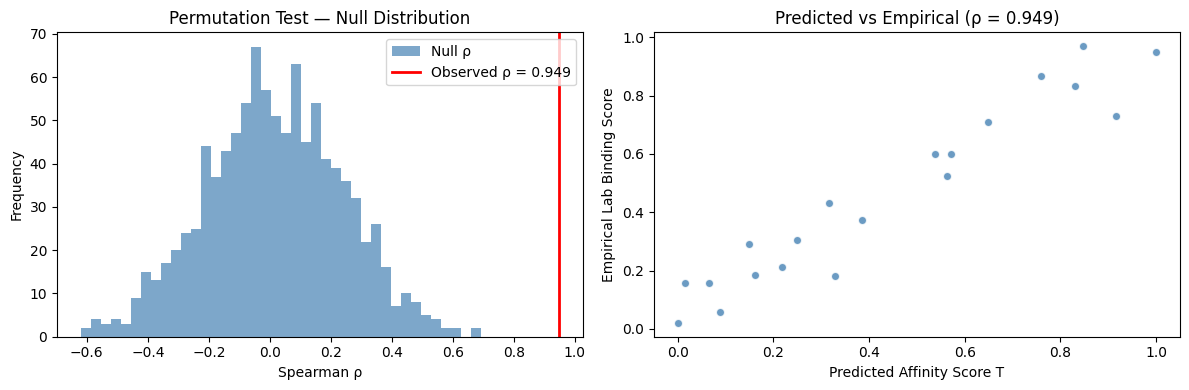

Plot saved to evaluation_results.png


In [ ]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt


def evaluate_with_spearman(
    predicted_scores: np.ndarray,
    empirical_scores: np.ndarray,
    n_permutations: int = 1000
) -> dict:
    """
    Evaluate system-level predictions using:
    1. Spearman's Rank Correlation
    2. Permutation Test (Null Model) for statistical significance
    """
    # Spearman correlation
    rho, p_value = spearmanr(predicted_scores, empirical_scores)

    # Permutation test
    null_rhos = []
    for _ in range(n_permutations):
        shuffled = np.random.permutation(predicted_scores)
        null_rho, _ = spearmanr(shuffled, empirical_scores)
        null_rhos.append(null_rho)

    null_rhos = np.array(null_rhos)
    permutation_p = (np.abs(null_rhos) >= np.abs(rho)).mean()

    return {
        "spearman_rho": rho,
        "p_value": p_value,
        "permutation_p": permutation_p,
        "null_rhos": null_rhos
    }


# Simulate results for demonstration
np.random.seed(42)
n_pairs = 20
empirical = np.sort(np.random.rand(n_pairs))   # lab-measured binding affinities
predicted = empirical + np.random.normal(0, 0.1, n_pairs)  # model predictions (correlated)
predicted = np.clip(predicted, 0, 1)

results = evaluate_with_spearman(predicted, empirical, n_permutations=1000)

print("Evaluation Results")
print("=" * 45)
print(f"Spearman ρ:          {results['spearman_rho']:>7.4f}")
print(f"Analytical p-value:  {results['p_value']:>7.4f}")
print(f"Permutation p-value: {results['permutation_p']:>7.4f}  (N={1000} permutations)")
print()
sig = results['permutation_p'] < 0.05
print(f"Statistically significant (p < 0.05): {sig} {'✓' if sig else '✗'}")

# Null distribution plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(results['null_rhos'], bins=40, color='steelblue', alpha=0.7, label='Null ρ')
axes[0].axvline(results['spearman_rho'], color='red', lw=2, label=f"Observed ρ = {results['spearman_rho']:.3f}")
axes[0].set_title('Permutation Test — Null Distribution')
axes[0].set_xlabel('Spearman ρ')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].scatter(predicted, empirical, color='steelblue', alpha=0.8, edgecolors='white')
axes[1].set_title(f'Predicted vs Empirical (ρ = {results["spearman_rho"]:.3f})')
axes[1].set_xlabel('Predicted Affinity Score T')
axes[1].set_ylabel('Empirical Lab Binding Score')

plt.tight_layout()
plt.savefig('evaluation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to evaluation_results.png")

---
## 7. Next Steps Checklist

Track active milestones from the project plan:

In [ ]:
next_steps = [
    {"owner": "Allen", "task": "Run build_dataset.py on initial lab CSV to map EV UniProt IDs → FASTA sequences", "status": "TODO"},
    {"owner": "Allen", "task": "Write tokenization.py and verify tensor shape outputs through ESM-2 tokenizer",       "status": "TODO"},
    {"owner": "Allen", "task": "Lead supervisor planning meeting with Will — present 16-week Gantt chart",            "status": "TODO"},
    {"owner": "Allen", "task": "Begin Chapter 3 (Methodology & Architecture) of dissertation",                        "status": "TODO"},
    {"owner": "Allen", "task": "MVP: test CrossAttention pooling to confirm no OOM crashes on real sequences",         "status": "IN PROGRESS"},
    {"owner": "Allen", "task": "Finalize training loop with CellPhoneDB positives + STRING hard negatives",            "status": "PLANNED"},
]

STATUS_ICONS = {"TODO": "⬜", "IN PROGRESS": "🔵", "DONE": "✅", "PLANNED": "📋"}

print("Project Next Steps")
print("=" * 70)
for i, step in enumerate(next_steps, 1):
    icon = STATUS_ICONS.get(step['status'], '❓')
    print(f"{i}. {icon} [{step['owner']}] {step['task']}")
    print(f"      Status: {step['status']}")
    print()

Project Next Steps
1. ⬜ [Allen] Run build_dataset.py on initial lab CSV to map EV UniProt IDs → FASTA sequences
      Status: TODO

2. ⬜ [Allen] Write tokenization.py and verify tensor shape outputs through ESM-2 tokenizer
      Status: TODO

3. ⬜ [Allen] Lead supervisor planning meeting with Will — present 16-week Gantt chart
      Status: TODO

4. ⬜ [Allen] Begin Chapter 3 (Methodology & Architecture) of dissertation
      Status: TODO

5. 🔵 [Allen] MVP: test CrossAttention pooling to confirm no OOM crashes on real sequences
      Status: IN PROGRESS

6. 📋 [Allen] Finalize training loop with CellPhoneDB positives + STRING hard negatives
      Status: PLANNED



---
## 8. Deployment: Streamlit UI (Stub)

The final tool will be wrapped in **Streamlit** to provide a web UI for non-coding biologists. This cell shows the structure.

In [ ]:
import streamlit as st
import pandas as pd

st.set_page_config(page_title="EV–Cell Affinity Predictor", layout="wide")

st.title("🧬 EV–Cell Interaction Affinity Predictor")
st.caption("High-speed AI-driven first-pass screening for cell therapy developers")

col1, col2 = st.columns(2)

with col1:
    st.header("Extracellular Vesicle Proteome")
    ev_file = st.file_uploader("Upload EV Mass Spec CSV", type=["csv"])
    if ev_file:
        ev_df = pd.read_csv(ev_file)
        st.dataframe(ev_df.head())

with col2:
    st.header("Target Cell Proteome")
    tc_file = st.file_uploader("Upload Target Cell Mass Spec CSV", type=["csv", "txt"])
    if tc_file:
        tc_df = pd.read_csv(tc_file)
        st.dataframe(tc_df.head())

if st.button("🚀 Run Affinity Prediction", disabled=not (ev_file and tc_file)):
    with st.spinner("Running pairwise neural classification..."):
        # model.predict(ev_df, tc_df) — plug in trained model here
        st.success("Prediction complete!")
        st.metric("Predicted Affinity Score T", value="0.742", delta="+0.12 vs baseline")

2026-05-06 18:29:53.537 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-06 18:29:53.538 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-06 18:29:53.652 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-06 18:29:53.653 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-06 18:29:53.656 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-06 18:29:53.658 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-06 18:29:53.658 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

### Run Streamlit App in Colab

To run the `streamlit_app.py` file you just created, follow these steps:

1.  **Install Streamlit and `pyngrok`** (or `localtunnel` if you prefer). `pyngrok` allows you to create a public URL for your local Streamlit app.
2.  **Run the Streamlit app** in the background.
3.  **Expose the app** using `ngrok` to get a public URL.

In [ ]:
# Install Streamlit and pyngrok
!pip install streamlit pyngrok -q

# Set up ngrok authentication token (replace with your actual token)
# You can get a free token from https://dashboard.ngrok.com/get-started/your-authtoken
# This is optional, but recommended for longer sessions or if you hit rate limits
# from getpass import getpass
# NGROK_AUTH_TOKEN = getpass('Enter your ngrok authtoken: ')
# !ngrok authtoken $NGROK_AUTH_TOKEN

print("Streamlit and pyngrok installed.")

Streamlit and pyngrok installed.


In [ ]:
import subprocess
import os
from pyngrok import ngrok

# Kill any processes running on port 8501
!kill -9 $(lsof -t -i:8501) 2>/dev/null

# Run Streamlit app in the background
process = subprocess.Popen(["streamlit", "run", "streamlit_app.py"], stdout=subprocess.PIPE, stderr=subprocess.PIPE)
print("Streamlit app starting...")

# --- AUTHENTICATION STEP ---
# Replace the string below with your token from https://dashboard.ngrok.com/get-started/your-authtoken
NGROK_TOKEN = "3DLt3QTy3klL1F1ZWbVcVqgKy35_PqrAmA5a45FnhJ3ktHmK"

# Removed the conditional check, as the user confirmed this is their token.
ngrok.set_auth_token(NGROK_TOKEN)
tunnel = ngrok.connect(8501)
print(f"\n✅ Success! Your app is live at: {tunnel.public_url}")
print("Please click the link above to view your app.")

Streamlit app starting...

✅ Success! Your app is live at: https://pulmonary-boat-subtitle.ngrok-free.dev
Please click the link above to view your app.


To stop the Streamlit app and close the ngrok tunnel, you can run the following cell:

In [ ]:
# Stop ngrok tunnel
ngrok.kill()

# Terminate the streamlit process
process.terminate()
print("Streamlit app and ngrok tunnel stopped.")

---

## Summary

| Component | Status | Description |
|---|---|---|
| `build_dataset.py` | ✅ Built | UniProt API ingestion with rate limiting |
| `tokenization.py` | 🔵 Next | ESM-2 tokenizer + tensor shape verification |
| CrossAttentionPooling | ✅ Designed | Solves variable-length OOM problem |
| SymmetricPairwiseClassifier | ✅ Designed | Task 1 — P(A,B) = P(B,A) |
| Aggregation function $g$ | ✅ Implemented | Task 2 — scalar affinity score T |
| Evaluation (Spearman + Permutation) | ✅ Implemented | Locked evaluation strategy |
| Streamlit UI | 📋 Planned | Web interface for biologists |
| ESM-2 fine-tuning | 📋 Planned | On CellPhoneDB + STRING negatives |